In [1]:
from ultralytics import YOLO
import supervision as sv
import cv2
import numpy as np

In [2]:
model = YOLO("yolov8n.pt")

In [3]:
tracker = sv.ByteTrack()

box_annotator = sv.BoxAnnotator()
label_annotator = sv.LabelAnnotator()

In [49]:
cap = cv2.VideoCapture("input_video.mp4")

width = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
height = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))
fps = int(cap.get(cv2.CAP_PROP_FPS))

print(width, height, fps)

1920 1080 30


In [50]:
fourcc = cv2.VideoWriter_fourcc(*'mp4v')

out = cv2.VideoWriter(
    "tracked_output.mp4",
    fourcc,
    fps,
    (width, height)
)

In [41]:

from collections import defaultdict

track_history = defaultdict(list)



In [42]:

import time

prev_time = 0



In [51]:

import csv

csv_file = open(
    "traffic_data.csv",
    mode="w",
    newline=""
)

csv_writer = csv.writer(csv_file)

csv_writer.writerow(
    [
        "Frame",
        "Visible Vehicles",
        "Cars",
        "Trucks",
        "Buses",
        "Motorcycles",
        "Traffic Status"
    ]
)



69

In [52]:
previous_positions = {}

counted_ids = set()

car_count = 0
truck_count = 0
bus_count = 0
motorcycle_count = 0
current_vehicle_count = 0

speed_history = {}

In [53]:

while True:

    ret, frame = cap.read()

    if not ret:
        break

    # Detect vehicles
    results = model(
        frame,
        classes=[2, 3, 5, 7],
        verbose=False
    )

    # Convert detections
    detections = sv.Detections.from_ultralytics(
        results[0]
    )

    # Update tracker
    detections = tracker.update_with_detections(
        detections
    )

    current_vehicle_count = len(detections)

    labels = []

    # Process each vehicle
    for tracker_id, class_id, xyxy in zip(
        detections.tracker_id,
        detections.class_id,
        detections.xyxy
    ):

        if tracker_id is None:
            continue

        class_name = model.names[class_id]

        labels.append(
            f"{class_name} ID:{tracker_id}"
        )

        x1, y1, x2, y2 = xyxy

        center_x = int((x1 + x2) / 2)
        center_y = int((y1 + y2) / 2)

               
        # Speed estimation
        if tracker_id in speed_history:
        
            prev_x, prev_y = speed_history[tracker_id]
        
            distance = np.sqrt(
                (center_x-prev_x)**2 +
                (center_y-prev_y)**2
            )
        
            speed = int(distance * 3)
        
        else:
        
            speed = 0
        
        speed_history[tracker_id] = (
            center_x,
            center_y
        )
        
        labels[-1] = (
            f"{class_name} ID:{tracker_id} "
            f"{speed} km/h"
        )


        
        # Draw center point
        cv2.circle(
            frame,
            (center_x, center_y),
            8,
            (255, 0, 0),
            -1
        )

        # Trajectory history
        track = track_history[tracker_id]

        track.append(
            (center_x, center_y)
        )

        if len(track) > 30:
            track.pop(0)

        # Draw trajectory
        for j in range(1, len(track)):

            cv2.line(
                frame,
                track[j-1],
                track[j],
                (255,255,0),
                3
            )

        # Counting logic
        if tracker_id in previous_positions:

            previous_x = previous_positions[tracker_id]

            crossed_line = (
                (previous_x < 1000 and center_x >= 1000)
                or
                (previous_x > 1000 and center_x <= 1000)
            )

            if crossed_line and tracker_id not in counted_ids:

                counted_ids.add(tracker_id)

                class_name = class_name.strip().lower()

                if class_name == "car":
                    car_count += 1

                elif class_name == "truck":
                    truck_count += 1

                elif class_name == "bus":
                    bus_count += 1

                elif class_name == "motorcycle":
                    motorcycle_count += 1

        previous_positions[tracker_id] = center_x

    # Traffic density
    if current_vehicle_count < 10:
        traffic_status = "LOW TRAFFIC"

    elif current_vehicle_count < 20:
        traffic_status = "MEDIUM TRAFFIC"

    elif current_vehicle_count < 30:
        traffic_status = "HIGH TRAFFIC"
    else: 
        traffic_status = "TRAFFIC CONGESTION"

    # Draw boxes
    frame = box_annotator.annotate(
        scene=frame,
        detections=detections
    )

    # Draw labels
    frame = label_annotator.annotate(
        scene=frame,
        detections=detections,
        labels=labels
    )

    # Draw counting line
    cv2.line(
        frame,
        (1000,0),
        (1000,1080),
        (0,0,255),
        12
    )

    # Display counts
    cv2.putText(
        frame,
        f"Cars: {car_count}",
        (50,70),
        cv2.FONT_HERSHEY_SIMPLEX,
        1.1,
        (0,255,0),
        3
    )
    density = int(
        current_vehicle_count / 30 * 100
    )

    density = min(density,100)
    cv2.putText(
        frame,
        f"Density: {density} %",
        (50,450),
        cv2.FONT_HERSHEY_SIMPLEX,
        1.2,
        (255,255,255),
        3
    )
    cv2.putText(
        frame,
        f"Trucks: {truck_count}",
        (50,120),
        cv2.FONT_HERSHEY_SIMPLEX,
        1.1,
        (0,255,0),
        3
    )

    cv2.putText(
        frame,
        f"Buses: {bus_count}",
        (50,170),
        cv2.FONT_HERSHEY_SIMPLEX,
        1.1,
        (0,255,0),
        3
    )

    cv2.putText(
        frame,
        f"Motorcycles: {motorcycle_count}",
        (50,220),
        cv2.FONT_HERSHEY_SIMPLEX,
        1.1,
        (0,255,0),
        3
    )

    cv2.putText(
        frame,
        traffic_status,
        (50,280),
        cv2.FONT_HERSHEY_SIMPLEX,
        1.2,
        (255,255,0),
        3
    )

    cv2.putText(
        frame,
        traffic_status,
        (50,400),
        cv2.FONT_HERSHEY_SIMPLEX,
        1.2,
        (0,0,255),
        3
    )

    # FPS Counter
    current_time = time.time()

    fps_display = int(
        1 / (current_time - prev_time)
    ) if prev_time != 0 else 0

    prev_time = current_time

    cv2.putText(
        frame,
        f"FPS: {fps_display}",
        (50,340),
        cv2.FONT_HERSHEY_SIMPLEX,
        1.2,
        (0,255,255),
        3
    )
    cv2.putText(
        frame,
        time.strftime("%H:%M:%S"),
        (1600,50),
        cv2.FONT_HERSHEY_SIMPLEX,
        1,
        (255,255,255),
        3
    )
    csv_writer.writerow( 
        [
            int(cap.get(cv2.CAP_PROP_POS_FRAMES)), 
            current_vehicle_count, car_count, 
            truck_count, 
            bus_count, 
            motorcycle_count, 
            traffic_status 
        ] 
    )
    out.write(frame)

cap.release()
out.release()
csv_file.close()
print("Processing Completed!")



Processing Completed!


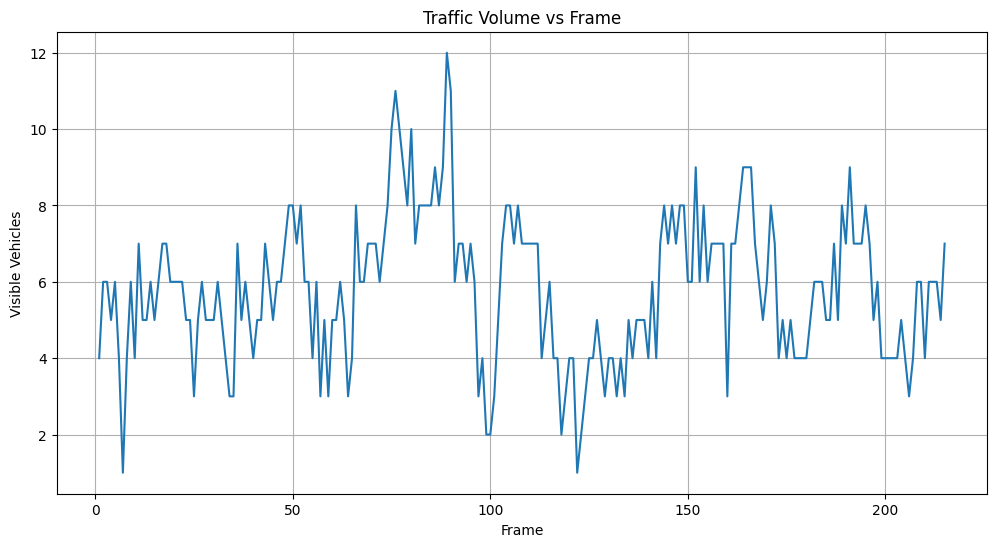

In [46]:

import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv("traffic_data.csv")

plt.figure(figsize=(12,6))

plt.plot(
    df["Frame"],
    df["Visible Vehicles"]
)

plt.xlabel("Frame")
plt.ylabel("Visible Vehicles")
plt.title("Traffic Volume vs Frame")

plt.grid()

plt.show()

